# **Exploratory Analysis**

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.config import get_path, BRAND_COLORS, VIZ_PARAMS
from src.data_loader import (download_wb_indicators, load_cbn_payments,
                              load_efina_summary, load_competitors)
from src.viz import apply_project_style, save_figure, plot_inclusion_trend, plot_payment_growth

apply_project_style()

# Load processed data
processed_dir = get_path("data_processed")
df_ng = pd.read_csv(processed_dir / "nigeria_combined.csv")
df_cbn = load_cbn_payments()
df_efina = load_efina_summary()
df_comp = load_competitors()

print(f"Nigeria combined: {df_ng.shape}")

Nigeria combined: (13, 32)


## Financial Inclusion Trend (2008–2023)

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig01_financial_inclusion_trend.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig01_financial_inclusion_trend.pdf


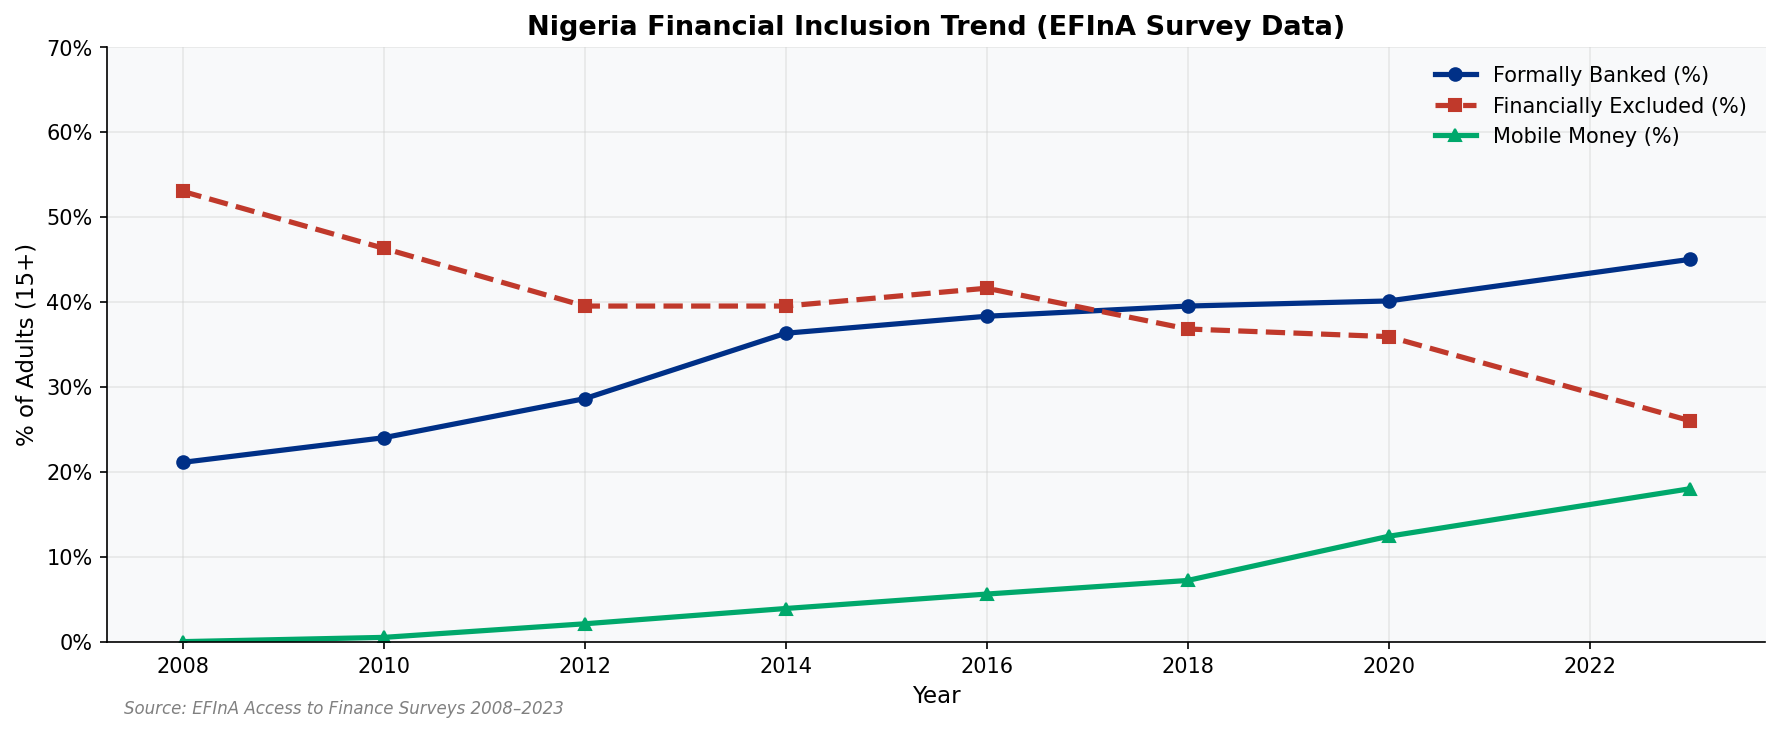


Key finding:
  Banked % rose from 21.1% (2008) to 45.0% (2023)
  Still, 26.0% of adults remain financially excluded
  Mobile money grew from 0% to 18.0%


In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_inclusion_trend(df_efina, ax=ax)
plt.tight_layout()
save_figure(fig, "fig01_financial_inclusion_trend.png")
plt.show()

print("\nKey finding:")
banked_08 = df_efina.loc[df_efina['year']==2008, 'banked_pct'].values[0]
banked_23 = df_efina.loc[df_efina['year']==2023, 'banked_pct'].values[0]
excl_23   = df_efina.loc[df_efina['year']==2023, 'excluded_pct'].values[0]
print(f"  Banked % rose from {banked_08}% (2008) to {banked_23}% (2023)")
print(f"  Still, {excl_23}% of adults remain financially excluded")
print(f"  Mobile money grew from 0% to {df_efina.loc[df_efina['year']==2023,'mobile_money_pct'].values[0]}%")

## E-Payment Volume and Value Growth

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig02_nip_payment_growth.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig02_nip_payment_growth.pdf


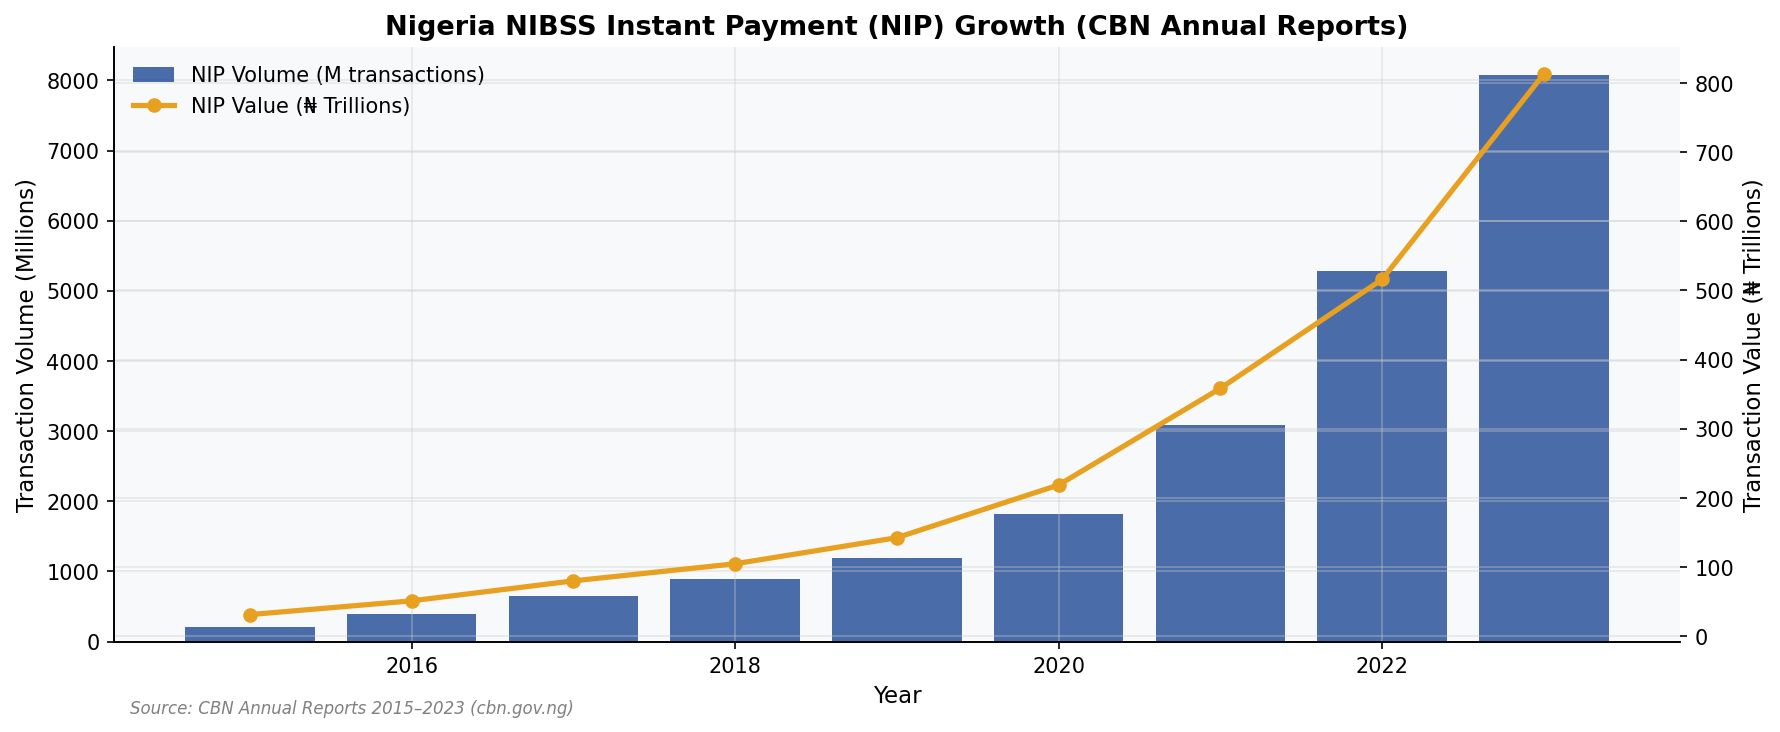


NIP volume CAGR (2015–2023): 57.9%/yr
NIP volume grew 39× in 8 years


In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_payment_growth(df_cbn, ax=ax)
plt.tight_layout()
save_figure(fig, "fig02_nip_payment_growth.png")
plt.show()

from src.stats import cagr
nip_cagr = cagr(df_cbn.iloc[0]['nip_volume_m'], df_cbn.iloc[-1]['nip_volume_m'], 8)
print(f"\nNIP volume CAGR (2015–2023): {nip_cagr*100:.1f}%/yr")
print(f"NIP volume grew {df_cbn.iloc[-1]['nip_volume_m']/df_cbn.iloc[0]['nip_volume_m']:.0f}× in 8 years")

## Multi-Channel Payment Dashboard

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig03_payment_channels_dashboard.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig03_payment_channels_dashboard.pdf


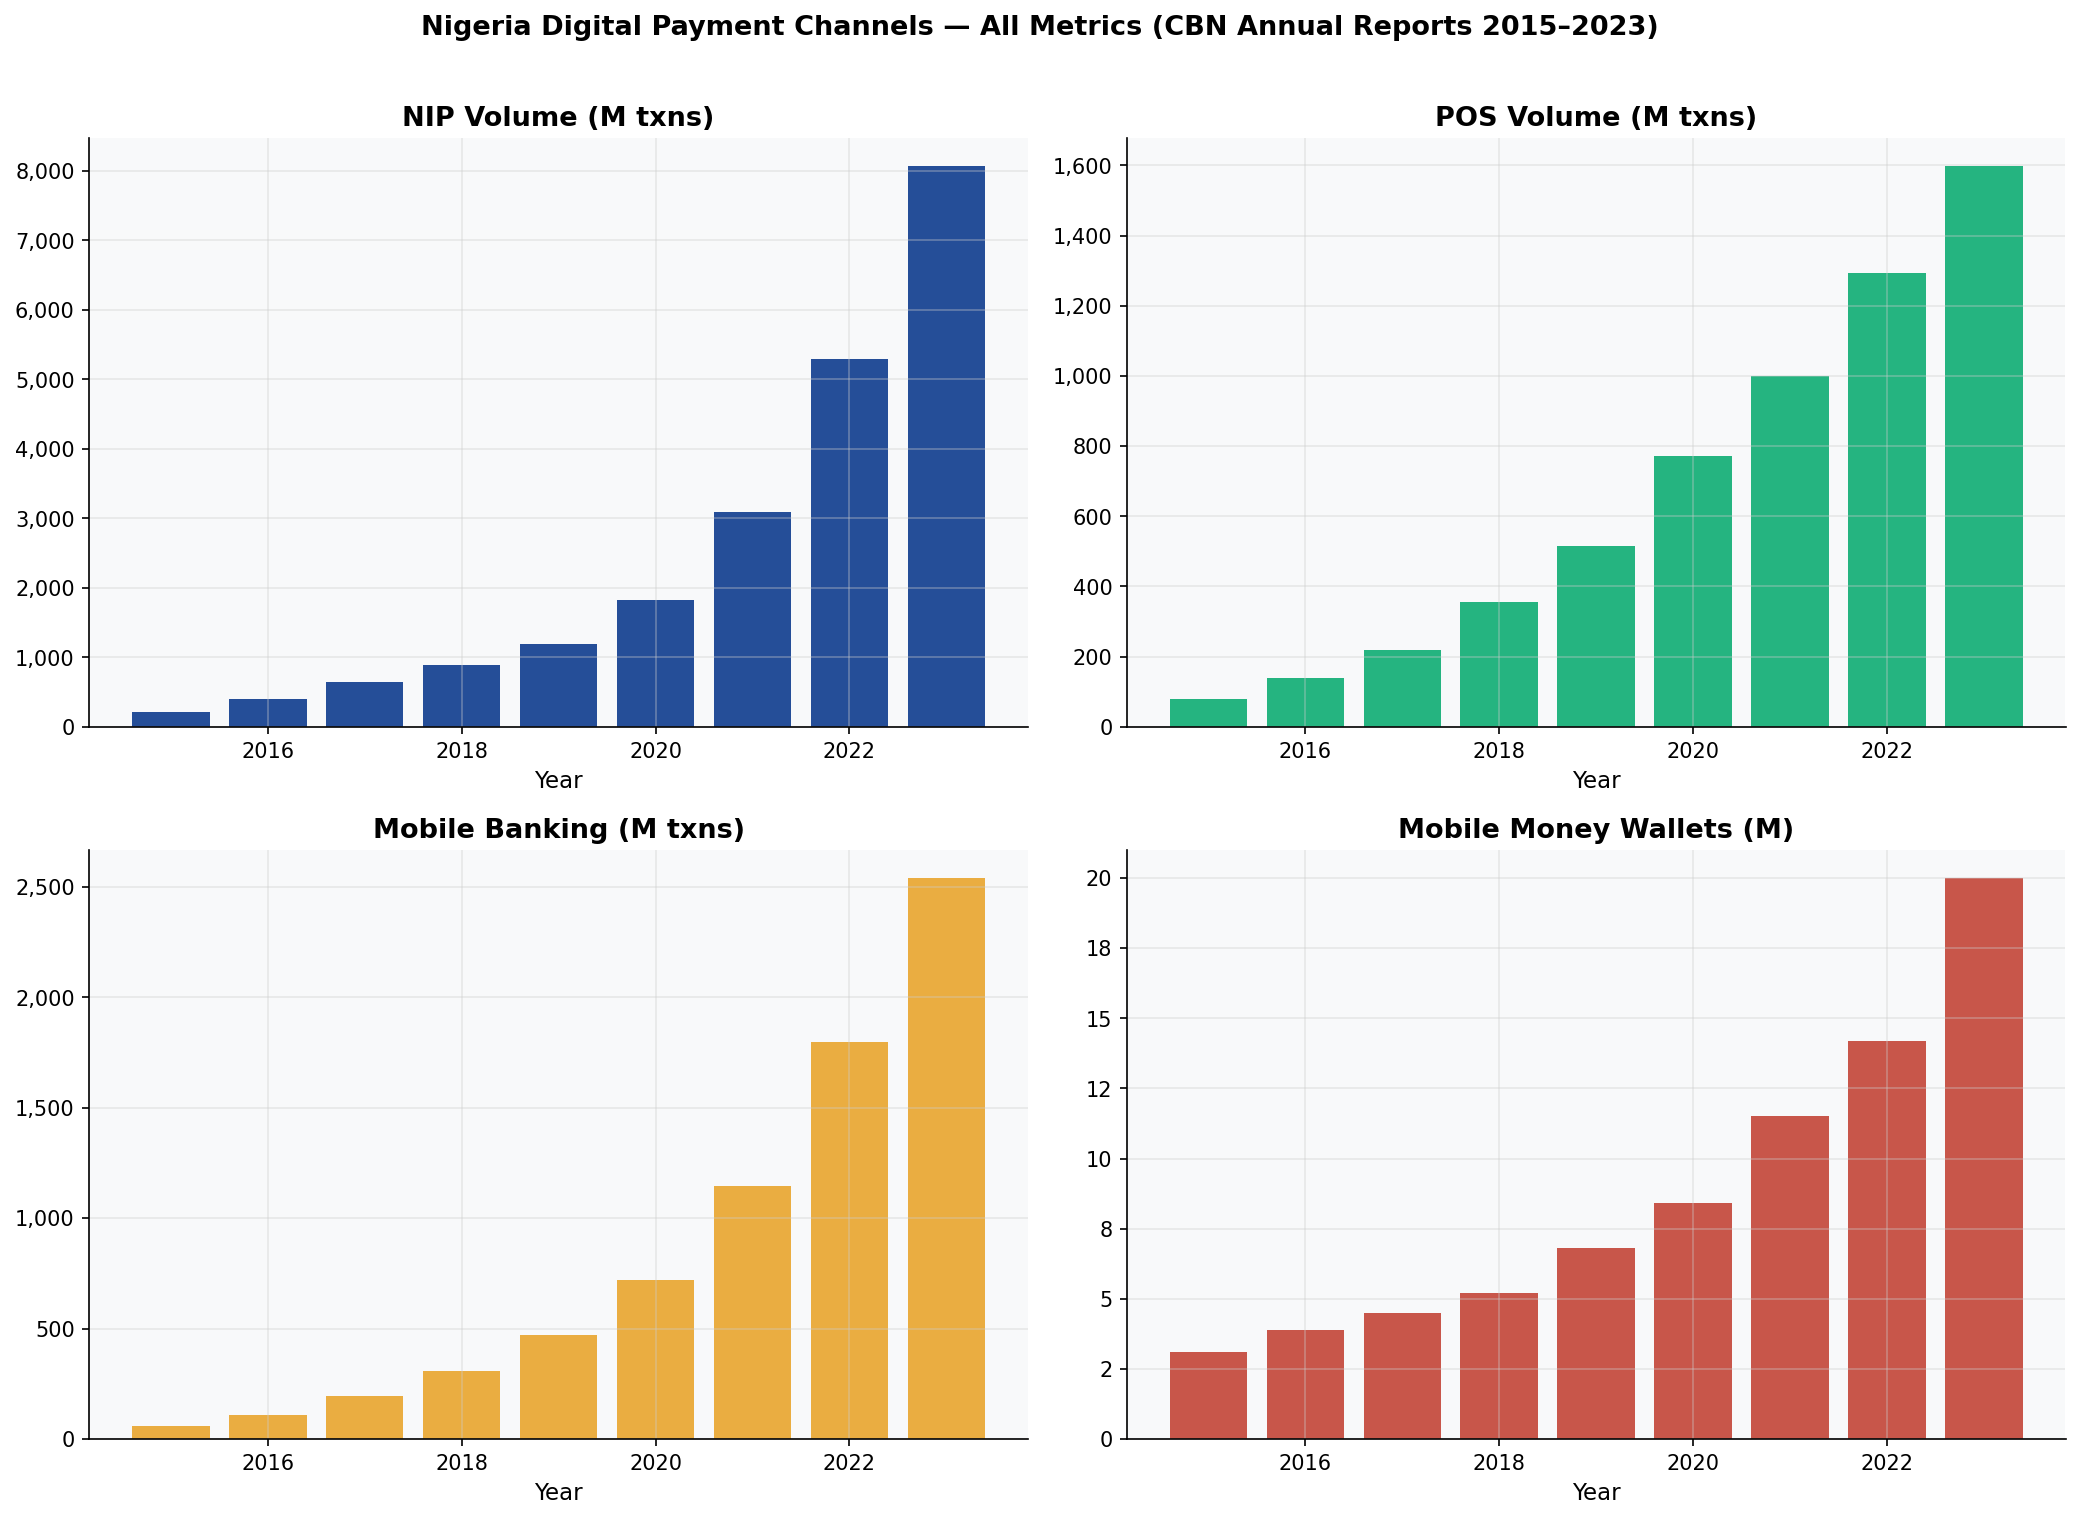

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
channels = [
    ('nip_volume_m',    'NIP Volume (M txns)',    BRAND_COLORS['primary']),
    ('pos_volume_m',    'POS Volume (M txns)',     BRAND_COLORS['secondary']),
    ('mobile_vol_m',    'Mobile Banking (M txns)', BRAND_COLORS['accent']),
    ('mobile_money_wallets_m', 'Mobile Money Wallets (M)', BRAND_COLORS['danger']),
]

for ax, (col, label, color) in zip(axes, channels):
    if col in df_cbn.columns:
        ax.bar(df_cbn['year'], df_cbn[col], color=color, alpha=0.85)
        ax.set_title(label)
        ax.set_xlabel("Year")
        ax.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'{x:,.0f}')
        )

plt.suptitle("Nigeria Digital Payment Channels — All Metrics (CBN Annual Reports 2015–2023)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
save_figure(fig, "fig03_payment_channels_dashboard.png")
plt.show()

## Cross-Country Financial Inclusion Comparison

Loading cached World Bank data from C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\data\raw\wb_indicators_raw.csv
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig04_cross_country_inclusion.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig04_cross_country_inclusion.pdf


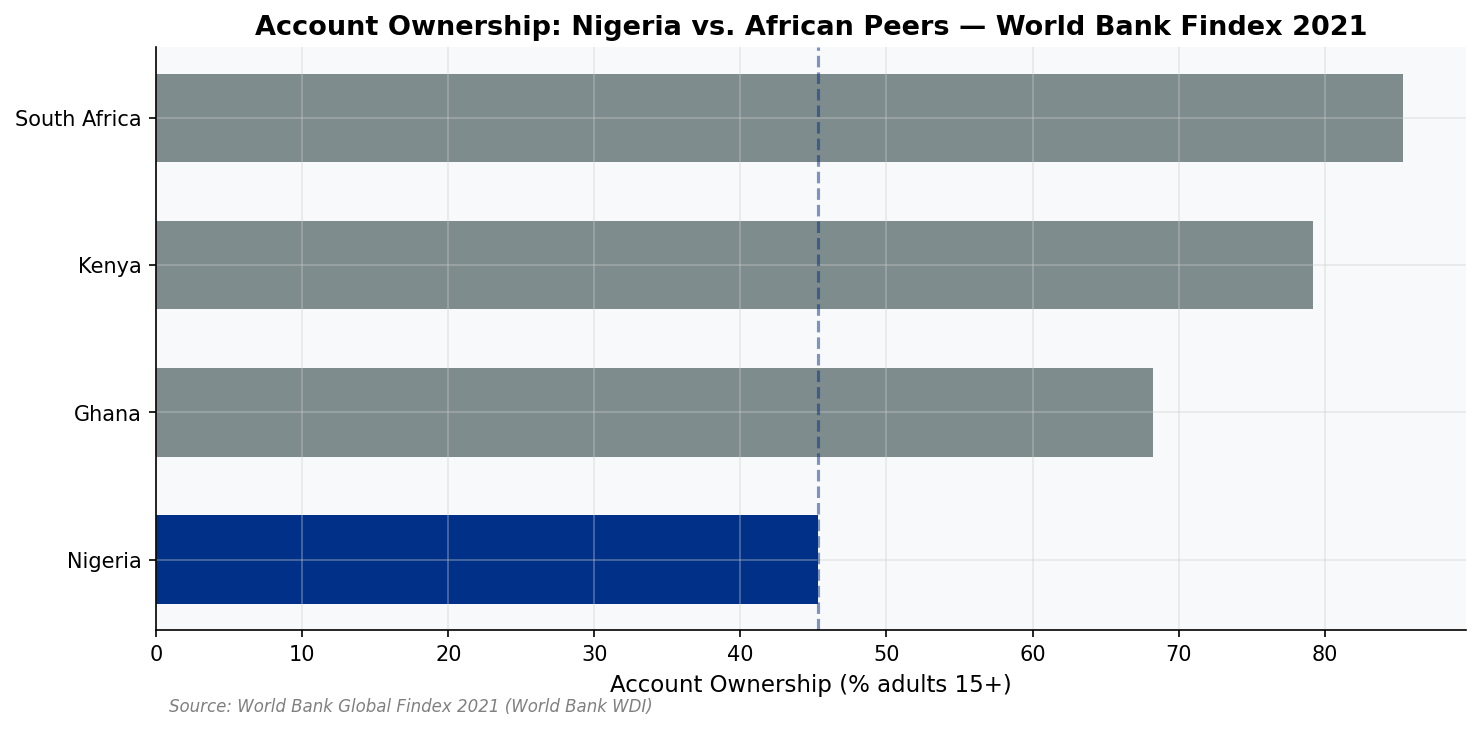

In [ ]:
# Data: World Bank WDI (Findex 2021 round)
df_wb = download_wb_indicators(cache=True)

peer_countries = ['Nigeria', 'Kenya', 'Ghana', 'South Africa', 'Egypt', 'Ethiopia']
df_peers = df_wb[
    (df_wb['indicator'] == 'account_ownership') &
    (df_wb['year'] == 2021) &
    (df_wb['country'].isin(peer_countries))
].dropna(subset=['value'])

df_peers = df_peers.sort_values('value', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [BRAND_COLORS['primary'] if c == 'Nigeria' else BRAND_COLORS['neutral']
          for c in df_peers['country']]
ax.barh(df_peers['country'], df_peers['value'], color=colors, height=0.6)
ax.set_xlabel("Account Ownership (% adults 15+)")
ax.set_title("Account Ownership: Nigeria vs. African Peers — World Bank Findex 2021")
ax.axvline(x=df_peers[df_peers['country']=='Nigeria']['value'].values[0] if len(df_peers[df_peers['country']=='Nigeria']) > 0 else 45,
           color=BRAND_COLORS['primary'], linestyle='--', alpha=0.5)
ax.annotate("Source: World Bank Global Findex 2021 (World Bank WDI)",
            xy=(0.01, -0.14), xycoords='axes fraction', fontsize=8, color='grey', style='italic')
plt.tight_layout()
save_figure(fig, "fig04_cross_country_inclusion.png")
plt.show()

## Macro Context: GDP, Mobile Penetration, Inflation

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig05_macro_context.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig05_macro_context.pdf


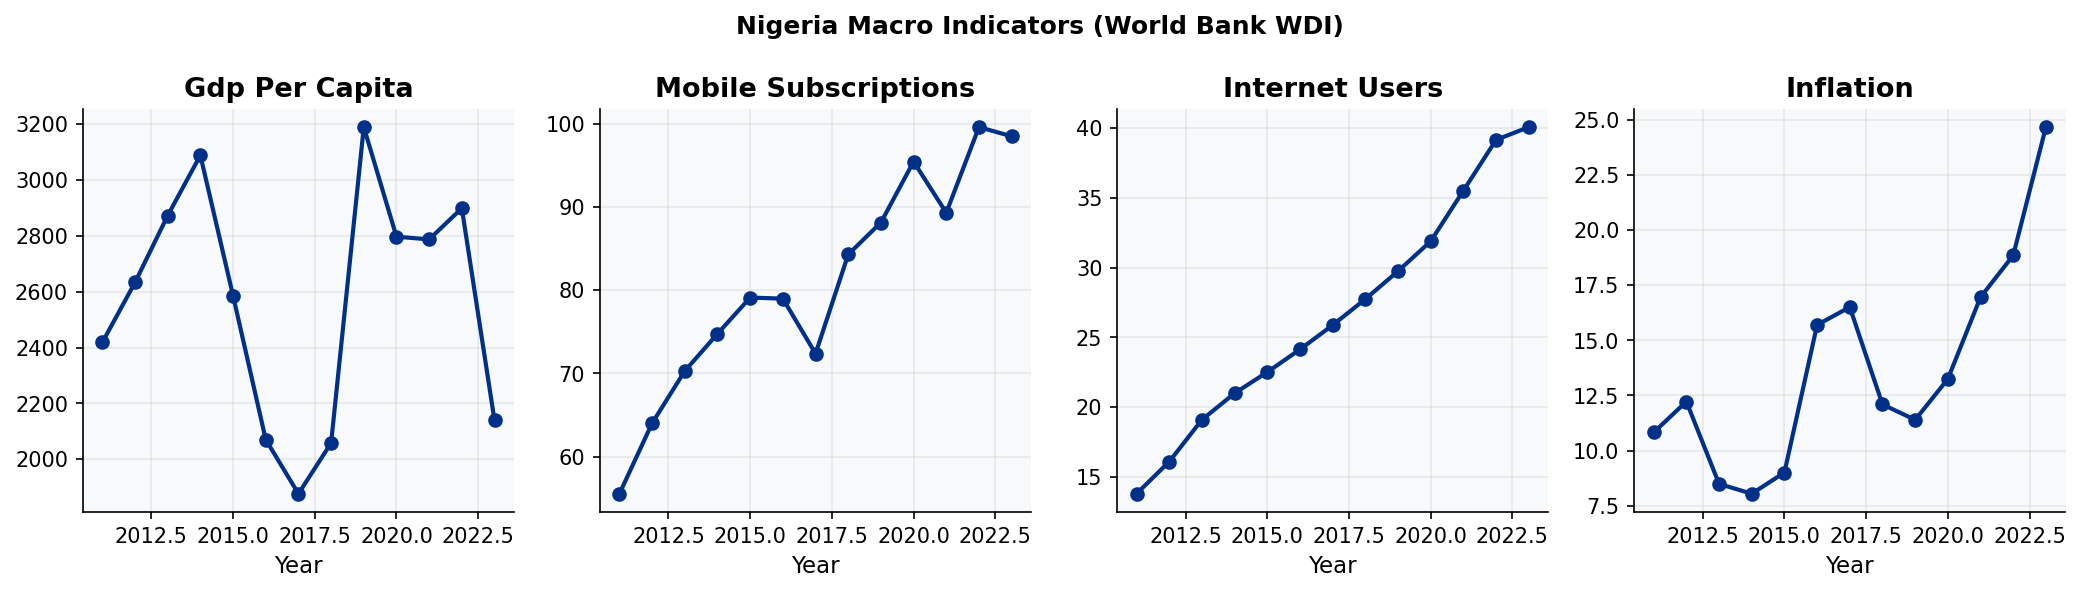

In [ ]:
macro_cols = ['gdp_per_capita', 'mobile_subscriptions', 'internet_users', 'inflation']
macro_available = [c for c in macro_cols if c in df_ng.columns]

if macro_available:
    fig, axes = plt.subplots(1, len(macro_available), figsize=(14, 4))
    if len(macro_available) == 1:
        axes = [axes]
    for ax, col in zip(axes, macro_available):
        sub = df_ng[['year', col]].dropna()
        ax.plot(sub['year'], sub[col], marker='o', color=BRAND_COLORS['primary'], linewidth=2)
        ax.set_title(col.replace('_', ' ').title())
        ax.set_xlabel("Year")
    plt.suptitle("Nigeria Macro Indicators (World Bank WDI)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    save_figure(fig, "fig05_macro_context.png")
    plt.show()
else:
    print("Macro columns not in combined dataset — check World Bank API download.")
    print("Available columns:", [c for c in df_ng.columns if not c.endswith('_yoy_pct')])